# Recreating Figure 1: Sex differences in daily variability

## Purpose

Recreate Figure 1 from Smarr et al. (2017), comparing locomotor activity (LA) and core body temperature (CBT) in female and male BALB/c mice.

## Data

Four CSV files contain one-minute LA or CBT measurements for 13 mice of each sex. Each file contains 14 days: the middle 12 days are analyzed, while the first and last days served as buffers for the paper's wavelet analysis.

## Questions / goals

- Reconstruct the four-day LA and CBT profiles in panels **a** and **c**.
- Calculate each animal's mean daily range (`daily maximum - daily minimum`).
- Compare females and males with and without estrus-aligned days, as in panels **b** and **d**.
- Document every assumption needed to reproduce the figure.

## Method choices from the paper

The Methods section specifies the following:

1. Analyze the middle 12 days from each 14-day recording.
2. Female analysis days 1, 5, and 9 are estrus-aligned; the same numbered days are excluded from males for a balanced comparison.
3. Define daily variability as each mouse's daily `max - min`, then average those daily ranges for each mouse. Thus, each boxplot contains 13 independent animal-level values.
4. Form a four-day trace by averaging the three repeated cycles within each animal, then averaging across the 13 animals. The caption calls this a *median* trace, but the Methods explicitly describe means; this notebook follows the Methods.
5. Compare sexes with a two-sided Wilcoxon rank-sum test. SciPy's `ranksums` implements its large-sample approximation, so exact values can differ slightly from MATLAB's reported rounded values.

The supplied CSVs appear to contain the paper's preprocessing already: CBT is floored at 35 °C and activity includes non-integer clipped caps. Applying the three-standard-deviation correction again would distort the analysis, so these files are treated as analysis-ready.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import ranksums

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({"figure.dpi": 120, "font.size": 10})

MINUTES_PER_DAY = 24 * 60
N_BUFFER_DAYS = 1
N_ANALYSIS_DAYS = 12
N_CYCLE_DAYS = 4
ESTRUS_DAYS_ZERO_BASED = (0, 4, 8)

def find_project_root(start: Path = Path.cwd()) -> Path:
    """Find the repository root whether the notebook starts there or below it."""
    for candidate in (start, *start.parents):
        if (candidate / "pyproject.toml").exists():
            return candidate
    raise FileNotFoundError("Could not find the project root containing pyproject.toml")

PROJECT_ROOT = find_project_root()
DATA_DIR = PROJECT_ROOT / "data" / "sex_diff_paper_data"
DATA_DIR

PosixPath('/home/vaugh/capstone-project/data/sex_diff_paper_data')

## Load and validate the data

Rows are consecutive one-minute observations; columns are individual mice. The assertions below make the expected study shape explicit before analysis.

In [2]:
file_map = {
    ("Female", "LA"): "fem_act.csv",
    ("Male", "LA"): "male_act.csv",
    ("Female", "CBT"): "fem_temp.csv",
    ("Male", "CBT"): "male_temp.csv",
}

recordings = {key: pd.read_csv(DATA_DIR / filename) for key, filename in file_map.items()}
expected_shape = (14 * MINUTES_PER_DAY, 13)

for key, frame in recordings.items():
    assert frame.shape == expected_shape, f"{key}: expected {expected_shape}, got {frame.shape}"
    assert not frame.isna().any().any(), f"{key}: missing values found"

data_overview = pd.DataFrame(
    [
        {
            "Sex": sex,
            "Measure": measure,
            "Rows": len(frame),
            "Mice": frame.shape[1],
            "Minimum": frame.min().min(),
            "Maximum": frame.max().max(),
        }
        for (sex, measure), frame in recordings.items()
    ]
)
data_overview

,Sex,Measure,Rows,Mice,Minimum,Maximum
0,Female,LA,20160,13,0.000000,133.037901
1,Male,LA,20160,13,0.000000,171.841532
2,Female,CBT,20160,13,35.034969,39.310000
3,Male,CBT,20160,13,35.000000,39.869739


## Select and reshape the 12 analysis days

Dropping exactly 1,440 rows from each end removes the two buffer days. Arrays are reshaped to `day × minute × mouse`, which makes the daily-range and four-day-cycle calculations visible.

In [3]:
def analysis_days(frame: pd.DataFrame) -> np.ndarray:
    """Return the middle 12 days as day × minute × mouse."""
    start = N_BUFFER_DAYS * MINUTES_PER_DAY
    stop = start + N_ANALYSIS_DAYS * MINUTES_PER_DAY
    values = frame.iloc[start:stop].to_numpy()
    return values.reshape(N_ANALYSIS_DAYS, MINUTES_PER_DAY, frame.shape[1])

arrays = {key: analysis_days(frame) for key, frame in recordings.items()}
{key: value.shape for key, value in arrays.items()}

{('Female', 'LA'): (12, 1440, 13),
 ('Male', 'LA'): (12, 1440, 13),
 ('Female', 'CBT'): (12, 1440, 13),
 ('Male', 'CBT'): (12, 1440, 13)}

## Recreate the summary traces and daily ranges

For the line plots, the three four-day windows are averaged within each mouse first. The result is then averaged across mice. For the boxplots, a range is calculated for every mouse-day and then averaged across the included days, leaving one value per mouse.

In [4]:
def four_day_profile(day_array: np.ndarray) -> np.ndarray:
    """Average three cycles within mouse, then average across mice."""
    cycles = day_array.reshape(3, N_CYCLE_DAYS, MINUTES_PER_DAY, day_array.shape[-1])
    mean_cycle_per_mouse = cycles.mean(axis=0)
    return mean_cycle_per_mouse.mean(axis=-1).reshape(-1)

def daily_ranges(day_array: np.ndarray) -> np.ndarray:
    """Calculate max - min for every day and mouse (day × mouse)."""
    return np.ptp(day_array, axis=1)

def mean_range_per_mouse(day_array: np.ndarray, exclude_estrus: bool = False) -> np.ndarray:
    ranges = daily_ranges(day_array)
    if exclude_estrus:
        ranges = np.delete(ranges, ESTRUS_DAYS_ZERO_BASED, axis=0)
    return ranges.mean(axis=0)

profiles = {key: four_day_profile(value) for key, value in arrays.items()}
range_values = {
    (sex, measure, condition): mean_range_per_mouse(arrays[(sex, measure)], exclude)
    for sex in ("Female", "Male")
    for measure in ("LA", "CBT")
    for condition, exclude in (("All days", False), ("Without estrus days", True))
}

range_summary = pd.DataFrame(
    [
        {
            "Measure": measure,
            "Days": condition,
            "Sex": sex,
            "Median mouse range": np.median(range_values[(sex, measure, condition)]),
            "Minimum mouse range": range_values[(sex, measure, condition)].min(),
            "Maximum mouse range": range_values[(sex, measure, condition)].max(),
        }
        for measure in ("LA", "CBT")
        for condition in ("All days", "Without estrus days")
        for sex in ("Female", "Male")
    ]
)
range_summary.round(3)

,Measure,Days,Sex,Median mouse range,Minimum mouse range,Maximum mouse range
0,LA,All days,Female,109.601,79.547,132.278
1,LA,All days,Male,135.202,115.160,169.451
2,LA,Without estrus days,Female,108.121,79.547,132.807
3,LA,Without estrus days,Male,135.126,115.880,168.655
4,CBT,All days,Female,2.808,2.280,2.929
5,CBT,All days,Male,3.344,2.757,4.821
6,CBT,Without estrus days,Female,2.809,2.304,2.914
7,CBT,Without estrus days,Male,3.344,2.709,4.826


## Sex comparisons

The test is applied to the 13 animal-level mean ranges per sex, not to all mouse-days as though they were independent observations.

In [5]:
test_results = []
for measure in ("LA", "CBT"):
    for condition in ("All days", "Without estrus days"):
        statistic, p_value = ranksums(
            range_values[("Female", measure, condition)],
            range_values[("Male", measure, condition)],
        )
        test_results.append(
            {
                "Measure": measure,
                "Days": condition,
                "Wilcoxon z": statistic,
                "p-value": p_value,
            }
        )

test_results = pd.DataFrame(test_results)
test_results.style.format({"Wilcoxon z": "{:.3f}", "p-value": "{:.3g}"})

,Measure,Days,Wilcoxon z,p-value
0,LA,All days,-3.821,0.000133
1,LA,Without estrus days,-3.821,0.000133
2,CBT,All days,-3.923,8.74e-05
3,CBT,Without estrus days,-3.872,0.000108


## Figure 1 replication

The recordings and source figure begin at circadian time 12 (CT12, lights off). Black bars therefore mark the 12-hour dark/active phase and white bars mark the 12-hour light/inactive phase. Plus symbols are Tukey boxplot outliers; asterisks mark the significant female–male comparisons.

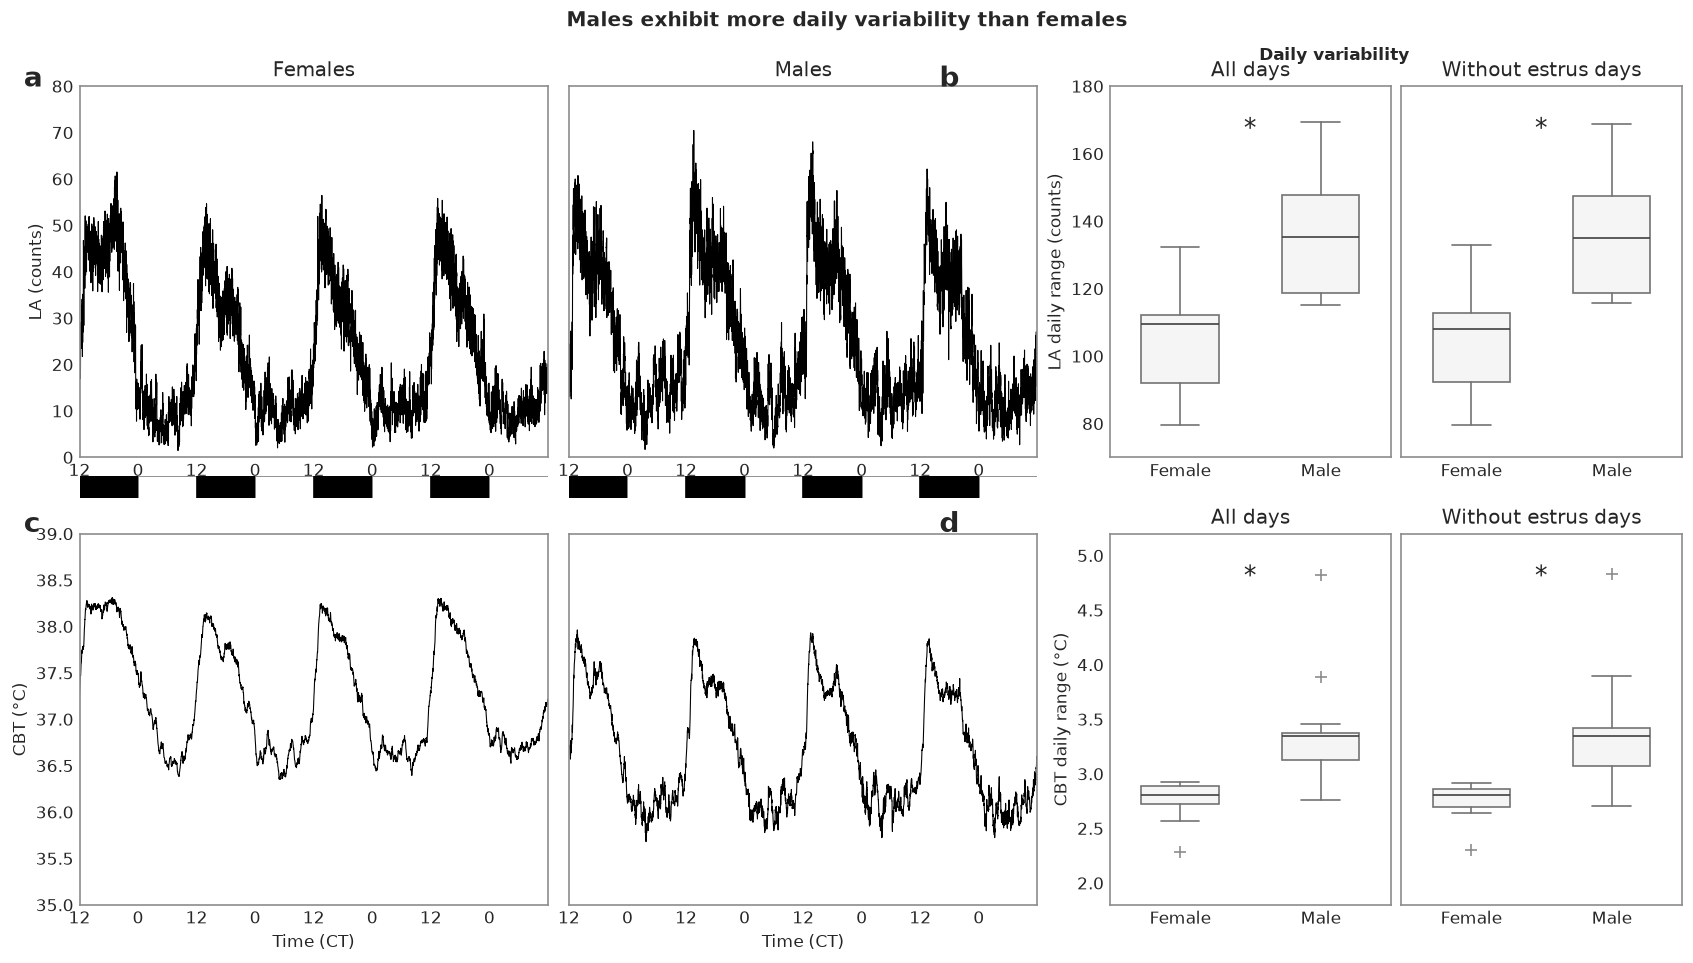

In [6]:
def add_light_dark_bar(ax: plt.Axes) -> None:
    """Add a four-day dark/light bar immediately below a trace axis."""
    bar = ax.inset_axes([0, -0.11, 1, 0.06], transform=ax.transAxes)
    for day in range(N_CYCLE_DAYS):
        bar.axvspan(day * 24, day * 24 + 12, color="black")
        bar.axvspan(day * 24 + 12, day * 24 + 24, color="white", ec="0.5", lw=0.5)
    bar.set(xlim=(0, 96), ylim=(0, 1))
    bar.axis("off")

def plot_trace(
    ax: plt.Axes,
    values: np.ndarray,
    title: str,
    ylabel: str,
    ylim: tuple,
    show_light_dark: bool = False,
) -> None:
    time_hours = np.arange(values.size) / 60
    ax.plot(time_hours, values, color="black", lw=0.65)
    ax.set(title=title, ylabel=ylabel, xlim=(0, 96), ylim=ylim)
    ax.set_xticks(np.arange(0, 96, 12), ["12", "0"] * 4)
    ax.grid(False)
    for spine in ax.spines.values():
        spine.set_color("0.55")
    if show_light_dark:
        add_light_dark_bar(ax)

def plot_range_boxplot(ax: plt.Axes, measure: str, condition: str, ylim: tuple) -> None:
    female = range_values[("Female", measure, condition)]
    male = range_values[("Male", measure, condition)]
    ax.boxplot(
        [female, male],
        tick_labels=["Female", "Male"],
        widths=0.55,
        patch_artist=True,
        boxprops={"facecolor": "0.96", "edgecolor": "0.45"},
        medianprops={"color": "0.25"},
        whiskerprops={"color": "0.45"},
        capprops={"color": "0.45"},
        flierprops={"marker": "+", "markeredgecolor": "0.55", "markersize": 7},
    )
    ax.set(title=condition, ylim=ylim)
    ax.grid(False)
    ax.text(1.5, ylim[1] - 0.08 * (ylim[1] - ylim[0]), "*", ha="center", va="top", fontsize=15)
    for spine in ax.spines.values():
        spine.set_color("0.55")

fig = plt.figure(figsize=(14, 7.5), constrained_layout=True)
grid = fig.add_gridspec(2, 4, width_ratios=[1.25, 1.25, 0.75, 0.75])

ax_la_f = fig.add_subplot(grid[0, 0])
ax_la_m = fig.add_subplot(grid[0, 1], sharey=ax_la_f)
ax_cbt_f = fig.add_subplot(grid[1, 0])
ax_cbt_m = fig.add_subplot(grid[1, 1], sharey=ax_cbt_f)
ax_la_all = fig.add_subplot(grid[0, 2])
ax_la_noe = fig.add_subplot(grid[0, 3], sharey=ax_la_all)
ax_cbt_all = fig.add_subplot(grid[1, 2])
ax_cbt_noe = fig.add_subplot(grid[1, 3], sharey=ax_cbt_all)

plot_trace(ax_la_f, profiles[("Female", "LA")], "Females", "LA (counts)", (0, 80), True)
plot_trace(ax_la_m, profiles[("Male", "LA")], "Males", "", (0, 80), True)
plot_trace(ax_cbt_f, profiles[("Female", "CBT")], "", "CBT (°C)", (35, 39))
plot_trace(ax_cbt_m, profiles[("Male", "CBT")], "", "", (35, 39))

plot_range_boxplot(ax_la_all, "LA", "All days", (70, 180))
plot_range_boxplot(ax_la_noe, "LA", "Without estrus days", (70, 180))
plot_range_boxplot(ax_cbt_all, "CBT", "All days", (1.8, 5.2))
plot_range_boxplot(ax_cbt_noe, "CBT", "Without estrus days", (1.8, 5.2))

ax_la_all.set_ylabel("LA daily range (counts)")
ax_cbt_all.set_ylabel("CBT daily range (°C)")
ax_la_m.tick_params(labelleft=False)
ax_cbt_m.tick_params(labelleft=False)
ax_la_noe.tick_params(labelleft=False)
ax_cbt_noe.tick_params(labelleft=False)
ax_cbt_f.set_xlabel("Time (CT)")
ax_cbt_m.set_xlabel("Time (CT)")

fig.text(0.01, 0.99, "a", fontsize=17, fontweight="bold", va="top")
fig.text(0.555, 0.99, "b", fontsize=17, fontweight="bold", va="top")
fig.text(0.01, 0.495, "c", fontsize=17, fontweight="bold", va="top")
fig.text(0.555, 0.495, "d", fontsize=17, fontweight="bold", va="top")
fig.text(0.79, 1.01, "Daily variability", ha="center", va="top", fontweight="bold")
fig.suptitle("Males exhibit more daily variability than females", y=1.05, fontweight="bold")
plt.show()

## Interpretation

The recreated figure supports the paper's main Figure 1 conclusions:

- Female four-day profiles show estrous-cycle structure that is not apparent in males.
- Male mice have larger animal-level daily ranges for both LA and CBT.
- Removing the estrus-aligned days changes little: the sex difference remains significant for both measures.
- The larger male CBT outlier and smaller female CBT outlier match the visual structure of the published boxplots.

Small visual or p-value differences from the published image can arise from plotting-library defaults, MATLAB/SciPy rank-sum implementations, and the paper's caption-versus-Methods mean/median wording. The notebook keeps those choices explicit rather than tuning hidden parameters to imitate the screenshot.